# RL Demo: Why We Need Policy Gradient Methods

A progressive demo using a 2D MuJoCo crawler. Each algorithm **works** on a simple setup, then **breaks** when we make the problem slightly more realistic.

| Demo | Algorithm | Works | Breaks | Bottleneck |
|------|-----------|-------|--------|------------|
| 1 | Tabular Q-learning | 2D state (joint angles) | 4D state (+velocities) | Curse of dimensionality |
| 2 | DQN | 4D continuous state | Continuous actions | Can't argmax over continuous actions |

**Punchline:** We need a method that directly outputs continuous actions → policy gradient methods.

In [1]:
# Setup - run this first
!pip install -q mujoco

import numpy as np
import mujoco
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import collections
import time

# Check if torch is available (pre-installed on Colab)
import torch
import torch.nn as nn
import torch.optim as optim

print(f'MuJoCo version: {mujoco.__version__}')
print(f'PyTorch version: {torch.__version__}')
print('Setup complete!')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
MuJoCo version: 3.6.0
PyTorch version: 2.11.0
Setup complete!


In [2]:
# ============================================================
# Crawler Environment
# ============================================================

CRAWLER_XML = """
<mujoco model="crawler2d">
  <compiler angle="degree" inertiafromgeom="true"/>
  <option timestep="0.005" gravity="0 0 -9.81" integrator="RK4"/>

  <default>
    <geom conaffinity="1" condim="3" friction="1.5 0.5 0.1" density="1000"/>
    <joint armature="0.1" damping="0.5"/>
  </default>

  <asset>
    <texture type="2d" name="grid" builtin="checker" width="512" height="512"
             rgb1="0.7 0.9 0.7" rgb2="0.6 0.85 0.6"/>
    <material name="grid" texture="grid" texrepeat="8 8"/>
  </asset>

  <worldbody>
    <light diffuse="0.8 0.8 0.8" pos="0 -2 3" dir="0 0.5 -1"/>
    <geom name="floor" type="plane" size="50 1 0.1" material="grid"/>

    <camera name="side" pos="0 -0.8 0.25" xyaxes="1 0 0 0 0.3 1" mode="trackcom"/>

    <body name="torso" pos="0 0 0.06">
      <joint name="root_x" type="slide" axis="1 0 0"/>
      <joint name="root_z" type="slide" axis="0 0 1"/>
      <joint name="root_rot" type="hinge" axis="0 1 0"/>

      <geom name="torso_geom" type="capsule" size="0.05"
            fromto="-0.1 0 0 0.1 0 0" rgba="0.3 0.7 0.3 1"/>

      <body name="arm" pos="0.1 0 0">
        <joint name="arm_joint" type="hinge" axis="0 1 0"
               range="-70 70" limited="true"/>
        <geom name="arm_geom" type="capsule" size="0.04"
              fromto="0 0 0 0.12 0 0" rgba="0.9 0.6 0.2 1"/>

        <body name="hand" pos="0.12 0 0">
          <joint name="hand_joint" type="hinge" axis="0 1 0"
                 range="-70 70" limited="true"/>
          <geom name="hand_geom" type="capsule" size="0.03"
                fromto="0 0 0 0.08 0 0" rgba="0.9 0.3 0.3 1"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor name="arm_motor" joint="arm_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="5"/>
    <motor name="hand_motor" joint="hand_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="3"/>
  </actuator>
</mujoco>
"""


class CrawlerEnv:
    """2D MuJoCo crawler with 2 actuated joints.
    
    State:  joint angles (and optionally velocities) - always continuous
    Action: 2D torque vector (continuous)
    Reward: forward (x) velocity
    """

    def __init__(self, include_velocity=False, max_steps=300, frame_skip=4):
        self.model = mujoco.MjModel.from_xml_string(CRAWLER_XML)
        self.data = mujoco.MjData(self.model)
        self.include_velocity = include_velocity
        self.max_steps = max_steps
        self.frame_skip = frame_skip
        self.steps = 0

        # Ranges for discretization
        self.angle_lo, self.angle_hi = np.deg2rad(-70), np.deg2rad(70)
        self.vel_lo, self.vel_hi = -8.0, 8.0

    # ---------- observation ----------
    def get_obs(self):
        """Return continuous observation."""
        arm_a, hand_a = self.data.qpos[3], self.data.qpos[4]
        if self.include_velocity:
            arm_v, hand_v = self.data.qvel[3], self.data.qvel[4]
            return np.array([arm_a, hand_a, arm_v, hand_v], dtype=np.float32)
        return np.array([arm_a, hand_a], dtype=np.float32)

    def discretize(self, obs, n_bins):
        """Convert continuous obs to a tuple of bin indices."""
        def _bin(val, lo, hi):
            val = np.clip(val, lo, hi)
            idx = int((val - lo) / (hi - lo) * n_bins)
            return min(idx, n_bins - 1)

        arm_b = _bin(obs[0], self.angle_lo, self.angle_hi)
        hand_b = _bin(obs[1], self.angle_lo, self.angle_hi)
        if len(obs) > 2:
            arm_vb = _bin(obs[2], self.vel_lo, self.vel_hi)
            hand_vb = _bin(obs[3], self.vel_lo, self.vel_hi)
            return (arm_b, hand_b, arm_vb, hand_vb)
        return (arm_b, hand_b)

    # ---------- dynamics ----------
    def reset(self):
        mujoco.mj_resetData(self.model, self.data)
        self.data.qpos[3] = np.random.uniform(-0.1, 0.1)
        self.data.qpos[4] = np.random.uniform(-0.1, 0.1)
        mujoco.mj_forward(self.model, self.data)
        self.steps = 0
        return self.get_obs()

    def step(self, ctrl):
        """ctrl: 2-element array of torques in [-1, 1]."""
        x_before = self.data.qpos[0]
        self.data.ctrl[:] = np.clip(ctrl, -1, 1)
        for _ in range(self.frame_skip):
            mujoco.mj_step(self.model, self.data)
        x_after = self.data.qpos[0]
        dt = self.frame_skip * self.model.opt.timestep
        reward = (x_after - x_before) / dt
        self.steps += 1
        truncated = self.steps >= self.max_steps
        return self.get_obs(), reward, False, truncated, {'x': x_after}


# ---------- Discrete action maps ----------
# 4 coarse actions: all combinations of +/- torque on each joint
ACTIONS_4 = {
    0: np.array([1.0, 1.0]),
    1: np.array([1.0, -1.0]),
    2: np.array([-1.0, 1.0]),
    3: np.array([-1.0, -1.0]),
}

def make_fine_actions(n_bins):
    """Create a grid of n_bins^2 discrete torque pairs."""
    torques = np.linspace(-1, 1, n_bins)
    actions = {}
    idx = 0
    for a in torques:
        for b in torques:
            actions[idx] = np.array([a, b])
            idx += 1
    return actions

print('Environment defined. Let\'s see what our crawler looks like!')

Environment defined. Let's see what our crawler looks like!


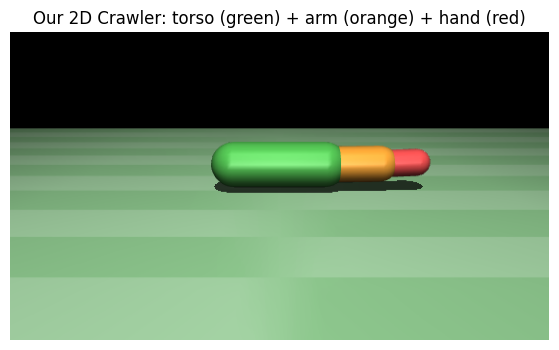

In [3]:
# ============================================================
# Visualization helpers
# ============================================================

def render_episode(env, policy_fn, max_steps=200, cam_name='side'):
    """Roll out a policy and collect rendered frames.
    
    policy_fn(obs) -> ctrl (2-element array of torques)
    """
    renderer = mujoco.Renderer(env.model, height=320, width=560)
    frames = []
    obs = env.reset()
    for _ in range(max_steps):
        renderer.update_scene(env.data, camera=cam_name)
        frames.append(renderer.render().copy())
        ctrl = policy_fn(obs)
        obs, _, terminated, truncated, _ = env.step(ctrl)
        if terminated or truncated:
            break
    renderer.close()
    return frames


def show_video(frames, fps=30, title=None):
    """Display frames as inline video."""
    fig, ax = plt.subplots(figsize=(8, 4))
    if title:
        ax.set_title(title, fontsize=14)
    ax.axis('off')
    im = ax.imshow(frames[0])
    def update(i):
        im.set_data(frames[i])
        return [im]
    anim = animation.FuncAnimation(fig, update, frames=len(frames),
                                   interval=1000/fps, blit=True)
    plt.close()
    return HTML(anim.to_html5_video())


def plot_rewards(rewards, window=50, title='Training Progress', ax=None):
    """Plot episode rewards with a smoothed average."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(rewards, alpha=0.3, color='steelblue')
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), smoothed, color='steelblue', linewidth=2)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax


# Quick test: render the crawler at rest
env = CrawlerEnv()
env.reset()
renderer = mujoco.Renderer(env.model, height=320, width=560)
renderer.update_scene(env.data, camera='side')
frame = renderer.render()
renderer.close()

plt.figure(figsize=(8, 4))
plt.imshow(frame)
plt.axis('off')
plt.title('Our 2D Crawler: torso (green) + arm (orange) + hand (red)')
plt.show()

---
## Demo 1: Tabular Q-learning **works** on coarse discrete states

**Setup:** The crawler's state is just **(arm angle, hand angle)**, discretized into 9 bins each → **81 total states**. There are **4 discrete actions** (all ± torque combos).

The Q-table is tiny: **81 × 4 = 324 entries**. Q-learning should fill this in quickly.

In [ ]:
# ============================================================
# Tabular Q-Learning
# ============================================================

def train_tabular_q(env, action_map, n_bins=9, n_episodes=2000,
                    lr=0.1, gamma=0.99, eps_start=1.0, eps_end=0.01,
                    eps_decay=0.995, verbose=True):
    """Train tabular Q-learning. Returns Q-table and reward history."""
    n_actions = len(action_map)

    # Determine Q-table shape from observation dimensionality
    test_obs = env.reset()
    test_state = env.discretize(test_obs, n_bins)
    q_shape = (n_bins,) * len(test_state) + (n_actions,)

    Q = np.zeros(q_shape)
    visit_count = np.zeros(q_shape[:-1], dtype=np.int32)  # track visits
    epsilon = eps_start
    rewards = []

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        state = env.discretize(obs, n_bins)
        total_reward = 0

        while True:
            # Epsilon-greedy action selection
            if np.random.random() < epsilon:
                action = np.random.randint(n_actions)
            else:
                action = np.argmax(Q[state])

            obs, reward, terminated, truncated, _ = env.step(action_map[action])
            next_state = env.discretize(obs, n_bins)
            done = terminated or truncated

            # Q-learning update
            best_next = np.max(Q[next_state]) if not terminated else 0
            td_target = reward + gamma * best_next
            Q[state + (action,)] += lr * (td_target - Q[state + (action,)])

            visit_count[state] += 1
            state = next_state
            total_reward += reward

            if done:
                break

        epsilon = max(eps_end, epsilon * eps_decay)
        rewards.append(total_reward)

        if verbose and (ep + 1) % 500 == 0:
            avg = np.mean(rewards[-100:])
            pct_visited = np.mean(visit_count > 0) * 100
            print(f'  Episode {ep+1:5d} | Avg reward: {avg:7.1f} | '
                  f'States visited: {pct_visited:.0f}% | eps: {epsilon:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')
        print(f'  Q-table shape: {Q.shape} ({Q.size} entries)')
        print(f'  States visited at least once: {np.mean(visit_count > 0)*100:.0f}%')

    return Q, visit_count, rewards

In [ ]:
# ---------- Demo 1: Tabular Q-learning on 2D state ----------
N_BINS = 9

print('=== Demo 1: Tabular Q-learning with 2D state (angles only) ===')
print(f'State space: {N_BINS}x{N_BINS} = {N_BINS**2} states')
print(f'Action space: 4 discrete actions')
print(f'Q-table size: {N_BINS**2 * 4} entries\n')

env_2d = CrawlerEnv(include_velocity=False, max_steps=200)

Q_2d, visits_2d, rewards_2d = train_tabular_q(
    env_2d, ACTIONS_4, n_bins=N_BINS, n_episodes=2000
)

In [ ]:
# Visualize the Q-table and training curve
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Training curve
plot_rewards(rewards_2d, title='Training Curve (2D state)', ax=axes[0])

# Value function: V(s) = max_a Q(s, a)
V_2d = Q_2d.max(axis=-1)
im = axes[1].imshow(V_2d, origin='lower', cmap='viridis', aspect='equal')
axes[1].set_xlabel('Hand angle bin')
axes[1].set_ylabel('Arm angle bin')
axes[1].set_title('Value Function V(s)')
plt.colorbar(im, ax=axes[1])

# Visit counts
im2 = axes[2].imshow(np.log1p(visits_2d), origin='lower', cmap='hot', aspect='equal')
axes[2].set_xlabel('Hand angle bin')
axes[2].set_ylabel('Arm angle bin')
axes[2].set_title('Log Visit Count')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [ ]:
# Watch the learned policy!
def q_policy_2d(obs):
    state = env_2d.discretize(obs, N_BINS)
    action = np.argmax(Q_2d[state])
    return ACTIONS_4[action]

frames_2d = render_episode(env_2d, q_policy_2d, max_steps=200)
print(f'Crawler traveled to x = {env_2d.data.qpos[0]:.3f}')
show_video(frames_2d, title='Tabular Q-learning: 2D state (works!)')

---
## Demo 2: Tabular Q-learning **breaks** with richer state

To control the crawler well, we should also know **how fast** the joints are moving — not just where they are.

Adding joint velocities makes the state **(arm_angle, hand_angle, arm_vel, hand_vel)** — a 4D space.

With 9 bins per dimension: **9^4 = 6,561 states** → Q-table has **26,244 entries**.

Sounds manageable? Let's see...

In [ ]:
# ---------- Demo 2: Tabular Q-learning on 4D state ----------
print('=== Demo 2: Tabular Q-learning with 4D state (angles + velocities) ===')
print(f'State space: {N_BINS}^4 = {N_BINS**4} states')
print(f'Q-table size: {N_BINS**4 * 4} entries  (vs {N_BINS**2 * 4} before)\n')

env_4d = CrawlerEnv(include_velocity=True, max_steps=200)

Q_4d, visits_4d, rewards_4d = train_tabular_q(
    env_4d, ACTIONS_4, n_bins=N_BINS, n_episodes=2000
)

In [ ]:
# Compare the two training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Training curves side by side
plot_rewards(rewards_2d, title='2D state (81 states) — WORKS', ax=axes[0])
plot_rewards(rewards_4d, title='4D state (6,561 states) — BREAKS', ax=axes[1])
axes[1].set_ylim(axes[0].get_ylim())  # same y-scale for fair comparison

plt.tight_layout()
plt.show()

# Show the sparsity problem
pct_2d = np.mean(visits_2d > 0) * 100
pct_4d = np.mean(visits_4d > 0) * 100
print(f'\nStates visited at least once:')
print(f'  2D state: {pct_2d:.0f}% of {N_BINS**2} states')
print(f'  4D state: {pct_4d:.0f}% of {N_BINS**4} states')
print(f'\nThe Q-table is mostly empty — the agent can\'t learn because')
print(f'it rarely revisits the same (angle, angle, velocity, velocity) combination.')

In [ ]:
# Watch the 4D policy (should be visibly worse)
def q_policy_4d(obs):
    state = env_4d.discretize(obs, N_BINS)
    action = np.argmax(Q_4d[state])
    return ACTIONS_4[action]

frames_4d = render_episode(env_4d, q_policy_4d, max_steps=200)
print(f'Crawler traveled to x = {env_4d.data.qpos[0]:.3f}')
show_video(frames_4d, title='Tabular Q-learning: 4D state (breaks!)')

### Why did it break?

**Curse of dimensionality.** Going from 2D → 4D state increased the table from 324 to 26,244 entries. Most states are never visited, so the Q-values there are meaningless.

And this is just 4 dimensions! A humanoid has ~60D state space. With 9 bins per dimension: **9^60 ≈ 10^57 states**. No table can hold that.

**Solution:** Instead of a table, use a **neural network** to approximate Q(s, a). Nearby states get similar Q-values — the network *generalizes*.

---
## Demo 3: DQN **fixes** the continuous state problem

Same 4D state (angles + velocities), same 4 discrete actions. But instead of a table, we use a small neural network:

```
obs (4D) → [64] → [64] → Q-values (4)
```

The network generalizes across similar states — no need to visit every state individually.

In [ ]:
# ============================================================
# DQN Agent
# ============================================================

class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        idxs = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idxs]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states, dtype=np.float32),
                np.array(actions, dtype=np.int64),
                np.array(rewards, dtype=np.float32),
                np.array(next_states, dtype=np.float32),
                np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)


def train_dqn(env, action_map, n_episodes=400, batch_size=64, gamma=0.99,
              lr=1e-3, eps_start=1.0, eps_end=0.01, eps_decay=0.995,
              target_update=100, buffer_size=20000, verbose=True):
    """Train DQN. Returns the trained network and reward history."""
    n_actions = len(action_map)
    obs_dim = len(env.reset())

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    q_net = QNetwork(obs_dim, n_actions).to(device)
    target_net = QNetwork(obs_dim, n_actions).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.Adam(q_net.parameters(), lr=lr)

    buffer = ReplayBuffer(buffer_size)
    epsilon = eps_start
    rewards = []
    total_steps = 0

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        total_reward = 0

        while True:
            # Epsilon-greedy
            if np.random.random() < epsilon:
                action = np.random.randint(n_actions)
            else:
                with torch.no_grad():
                    q_vals = q_net(torch.FloatTensor(obs).unsqueeze(0).to(device))
                    action = q_vals.argmax(dim=1).item()

            next_obs, reward, terminated, truncated, _ = env.step(action_map[action])
            done = terminated or truncated
            buffer.push(obs, action, reward, next_obs, float(terminated))

            obs = next_obs
            total_reward += reward
            total_steps += 1

            # Training step
            if len(buffer) >= batch_size:
                s, a, r, ns, d = buffer.sample(batch_size)
                s_t = torch.FloatTensor(s).to(device)
                a_t = torch.LongTensor(a).to(device)
                r_t = torch.FloatTensor(r).to(device)
                ns_t = torch.FloatTensor(ns).to(device)
                d_t = torch.FloatTensor(d).to(device)

                q_values = q_net(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_q = target_net(ns_t).max(dim=1)[0]
                    target = r_t + gamma * next_q * (1 - d_t)

                loss = nn.functional.mse_loss(q_values, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Target network update
            if total_steps % target_update == 0:
                target_net.load_state_dict(q_net.state_dict())

            if done:
                break

        epsilon = max(eps_end, epsilon * eps_decay)
        rewards.append(total_reward)

        if verbose and (ep + 1) % 100 == 0:
            avg = np.mean(rewards[-50:])
            print(f'  Episode {ep+1:4d} | Avg reward: {avg:7.1f} | eps: {epsilon:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    return q_net, rewards

In [ ]:
# ---------- Demo 3: DQN on 4D state, 4 discrete actions ----------
print('=== Demo 3: DQN with 4D continuous state, 4 discrete actions ===')
print(f'State: 4D continuous (arm angle, hand angle, arm vel, hand vel)')
print(f'Actions: 4 discrete (same as before)')
print(f'Q-function: neural network (4 → 64 → 64 → 4)\n')

env_dqn = CrawlerEnv(include_velocity=True, max_steps=300)

q_net_4, rewards_dqn_4 = train_dqn(
    env_dqn, ACTIONS_4, n_episodes=400
)

In [ ]:
# Compare: tabular 4D (broken) vs DQN 4D (works)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_rewards(rewards_4d, title='Tabular Q on 4D state (BROKEN)', ax=axes[0])
plot_rewards(rewards_dqn_4, title='DQN on 4D state (WORKS)', ax=axes[1])

# Use same y-scale
ymin = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(ymin, ymax)
axes[1].set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

In [ ]:
# Watch the DQN policy
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def dqn_policy_4(obs):
    with torch.no_grad():
        q_vals = q_net_4(torch.FloatTensor(obs).unsqueeze(0).to(device))
        action = q_vals.argmax(dim=1).item()
    return ACTIONS_4[action]

frames_dqn = render_episode(env_dqn, dqn_policy_4, max_steps=200)
print(f'Crawler traveled to x = {env_dqn.data.qpos[0]:.3f}')
show_video(frames_dqn, title='DQN: 4D continuous state, 4 discrete actions (works!)')

---
## Demo 4: DQN **breaks** with continuous actions

Our 4 discrete actions (all combos of ±1 torque) are crude — real motors apply **continuous torques**.

DQN needs `argmax_a Q(s, a)` — easy when there are 4 actions, but **impossible** when actions are continuous (infinite choices).

Workaround: discretize torques into a grid. Let's try:
- **Coarse:** 3 torque levels per joint → 9 actions
- **Fine:** 7 torque levels per joint → 49 actions
- **Very fine:** 11 levels → 121 actions

In [ ]:
# ---------- Demo 4: DQN struggles with discretized continuous actions ----------

results = {}

for n_torque_bins, n_eps in [(3, 400), (7, 600), (11, 800)]:
    action_map = make_fine_actions(n_torque_bins)
    n_act = len(action_map)
    print(f'\n=== DQN with {n_torque_bins} torque levels → {n_act} actions ===')

    env_cont = CrawlerEnv(include_velocity=True, max_steps=300)

    q_net, rews = train_dqn(
        env_cont, action_map, n_episodes=n_eps,
        eps_decay=0.997, lr=5e-4  # slower exploration decay for harder problem
    )
    results[n_torque_bins] = (q_net, rews, action_map)

In [ ]:
# Compare all DQN results
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Reference: DQN with 4 actions (works)
plot_rewards(rewards_dqn_4, title='4 actions (WORKS)', ax=axes[0])

for i, (n_bins, (_, rews, _)) in enumerate(results.items()):
    n_act = n_bins ** 2
    plot_rewards(rews, title=f'{n_act} actions ({n_bins} per joint)', ax=axes[i+1])

# Same y-scale across all plots
all_ylims = [ax.get_ylim() for ax in axes]
ymin = min(y[0] for y in all_ylims)
ymax = max(y[1] for y in all_ylims)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

print('\nAs we increase action resolution, DQN struggles more:')
print(f'  4 actions:   avg last-50 reward = {np.mean(rewards_dqn_4[-50:]):.1f}')
for n_bins, (_, rews, _) in results.items():
    print(f'  {n_bins**2:3d} actions: avg last-50 reward = {np.mean(rews[-50:]):.1f}')

In [ ]:
# Animate the worst case (most actions) to show the jerky/failed behavior
worst_bins = max(results.keys())
worst_net, _, worst_actions = results[worst_bins]

env_show = CrawlerEnv(include_velocity=True, max_steps=200)

def dqn_policy_fine(obs):
    with torch.no_grad():
        q_vals = worst_net(torch.FloatTensor(obs).unsqueeze(0).to(device))
        action = q_vals.argmax(dim=1).item()
    return worst_actions[action]

frames_fine = render_episode(env_show, dqn_policy_fine, max_steps=200)
print(f'Crawler traveled to x = {env_show.data.qpos[0]:.3f}')
show_video(frames_fine, title=f'DQN with {worst_bins**2} discretized actions (breaks!)')

### Why did DQN break?

DQN needs to evaluate **every possible action** to pick the best one (argmax). When we discretize continuous torques:

- **Too few bins (coarse):** The controller can't produce smooth motion — like driving a car where the steering wheel only has 3 positions.
- **Too many bins (fine):** The action space explodes. The network struggles to figure out that torque=0.71 is almost as good as torque=0.73.

For a real robot with 20 joints, even 3 torque levels per joint gives **3^20 ≈ 3.5 billion** discrete actions. Impossible.

---

### What we need

Instead of asking *"which of these N discrete actions is best?"*, we need a method that **directly outputs continuous values**:

$$\pi_\theta(s) \rightarrow a \in \mathbb{R}^n$$

A **policy network** that takes the state and directly outputs torques. No argmax, no enumeration.

How do we train it? **Policy gradient methods** — the topic of the next lecture.

The idea: instead of learning Q-values and deriving a policy, directly optimize the policy parameters by gradient ascent on expected reward.

---
## Summary

| Method | State | Actions | Result | Bottleneck |
|--------|-------|---------|--------|------------|
| Tabular Q | 2D discrete (81 states) | 4 discrete | Works | — |
| Tabular Q | 4D discrete (6,561 states) | 4 discrete | **Breaks** | Table too sparse |
| DQN | 4D continuous | 4 discrete | Works | — |
| DQN | 4D continuous | Fine discrete (49-121) | **Breaks** | argmax over too many actions |
| Policy gradient | 4D continuous | **Continuous** | Next lecture! | — |

**Key insight:** Each method has a fundamental limitation that the next method solves.
- Tables can't handle high-dimensional states → neural nets
- Q-learning can't handle continuous actions → policy gradients